In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [3]:
pd.set_option('display.max_columns', None)

In [6]:
df = pd.read_csv('bank-full.csv', sep=';')

In [7]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


### Phase 1: Data Cleaning & Preprocessing
We will map the target variable 'y' to binary integers (1 for yes, 0 for no) and inspect the dataset for 'unknown' entries.

In [8]:
# Convert target variable 'y' to numeric
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Check for 'unknown' values in categorical columns
cat_columns = df.select_dtypes(include=['object']).columns
for col in cat_columns:
    unknown_count = (df[col] == 'unknown').sum()
    print(f"{col}: {unknown_count} unknowns")

display(df.head())

job: 330 unknowns
marital: 80 unknowns
education: 1731 unknowns
default: 8597 unknowns
housing: 990 unknowns
loan: 990 unknowns
contact: 0 unknowns
month: 0 unknowns
day_of_week: 0 unknowns
poutcome: 0 unknowns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [14]:
# Check initial count
initial_rows = df.shape[0]

# Remove duplicates
df = df.drop_duplicates()

# Calculate how many were removed
removed = initial_rows - df.shape[0]
print(f"Removed {removed} duplicate rows. New dataset size: {df.shape[0]}")

Removed 14 duplicate rows. New dataset size: 41174


### Phase 2: Exploratory Data Analysis (EDA)
We will now visualize the data to identify key drivers for lead conversion.

### 1. Overall Subscription Rate
This baseline shows the percentage of people who subscribed vs. those who didn't.

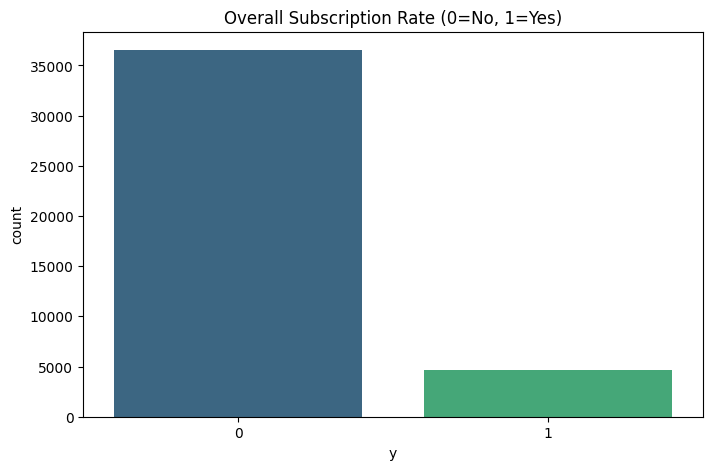

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(x='y', data=df, palette='viridis', hue='y', legend=False)
plt.title('Overall Subscription Rate (0=No, 1=Yes)')
plt.show()

**Findings:** The dataset is imbalanced. Most customers (approx. 88%) do not subscribe. This means our 'Hot Lead' scoring is crucial because calling everyone would be highly inefficient.

### 2. Conversion Rate by Job
This helps us identify which professions (like 'retired' or 'student') are most likely to subscribe.

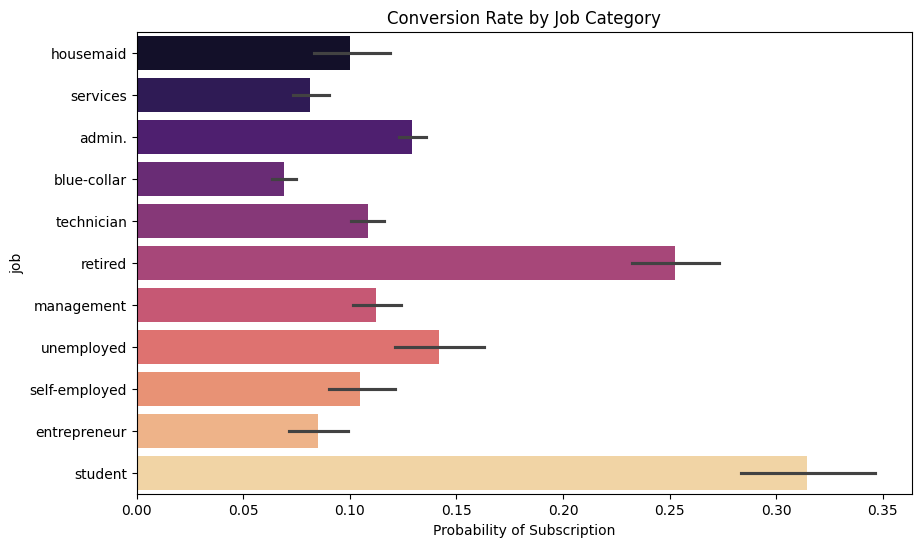

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(x='y', y='job', data=df, estimator=np.mean, palette='magma', hue='job', legend=False)
plt.title('Conversion Rate by Job Category')
plt.xlabel('Probability of Subscription')
plt.show()

**Findings:** 'Retired' and 'Student' categories show the highest conversion rates. The 'Blue-collar' sector represents a large volume but has a lower conversion probability.

### 3. Economic Context: Consumer Confidence
We analyze if subscribers tend to have higher or lower consumer confidence during the campaign.

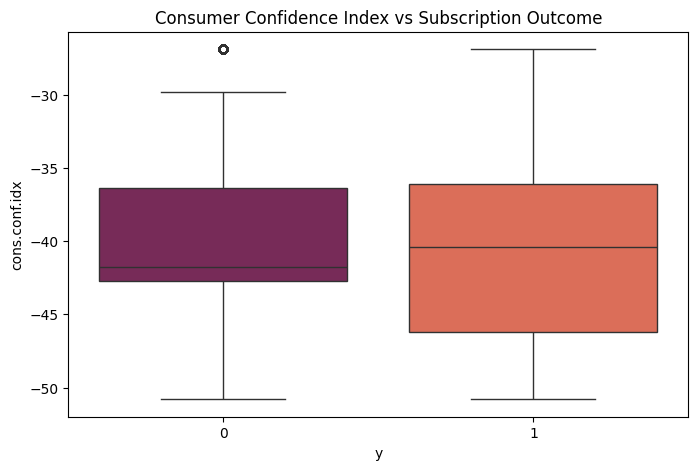

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='cons.conf.idx', data=df, palette='rocket', hue='y', legend=False)
plt.title('Consumer Confidence Index vs Subscription Outcome')
plt.show()

**Findings:** There is a correlation between consumer confidence and subscription. Leads tend to subscribe more when the confidence index is higher, suggesting economic optimism drives investment.

### 4. Education Level Impact
Let's see if the user's level of education correlates with their likelihood to open a term deposit.

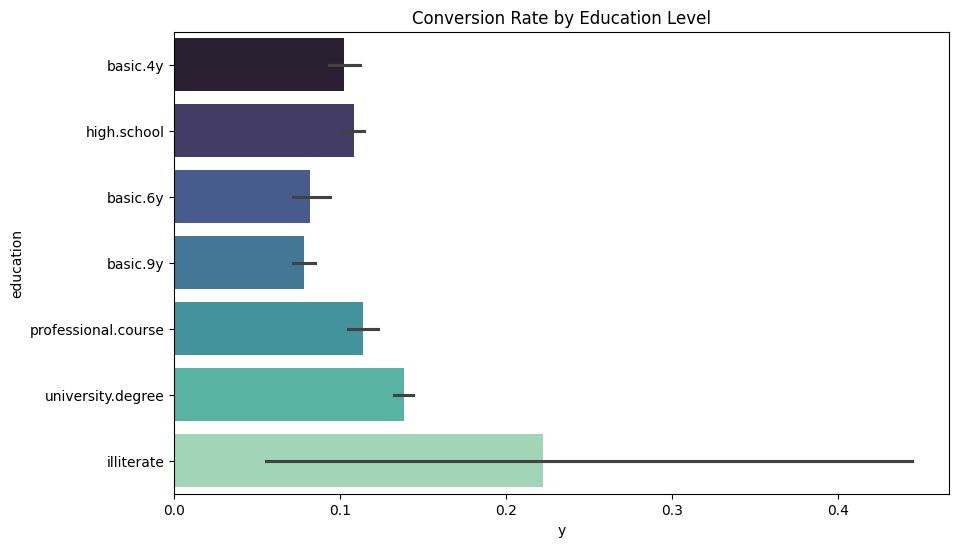

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='y', y='education', data=df, estimator=np.mean, palette='mako', hue='education', legend=False)
plt.title('Conversion Rate by Education Level')
plt.show()

**Findings:** Customers with a 'University Degree' or 'Professional Course' background are more likely to subscribe compared to those with basic education levels.

### 5. The Golden Window: Call Duration
Finally, we look at how the length of the phone call relates to the final decision.

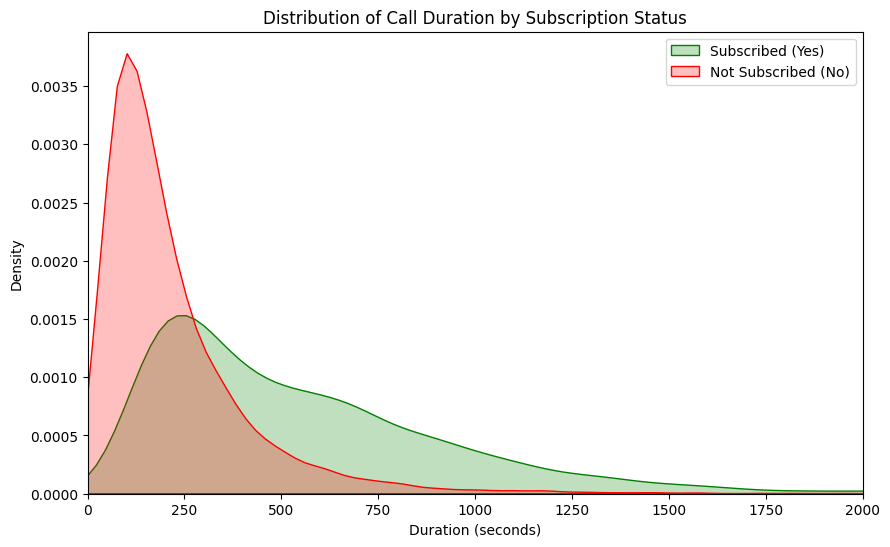

In [21]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['y'] == 1]['duration'], label='Subscribed (Yes)', fill=True, color='green')
sns.kdeplot(df[df['y'] == 0]['duration'], label='Not Subscribed (No)', fill=True, color='red')
plt.title('Distribution of Call Duration by Subscription Status')
plt.xlabel('Duration (seconds)')
plt.xlim(0, 2000)
plt.legend()
plt.show()

### 6. Economic Feature Correlation
This chart identifies if features like 'Interest Rates' and 'Number of Employees' are too similar to each other, which can lead to redundancy.

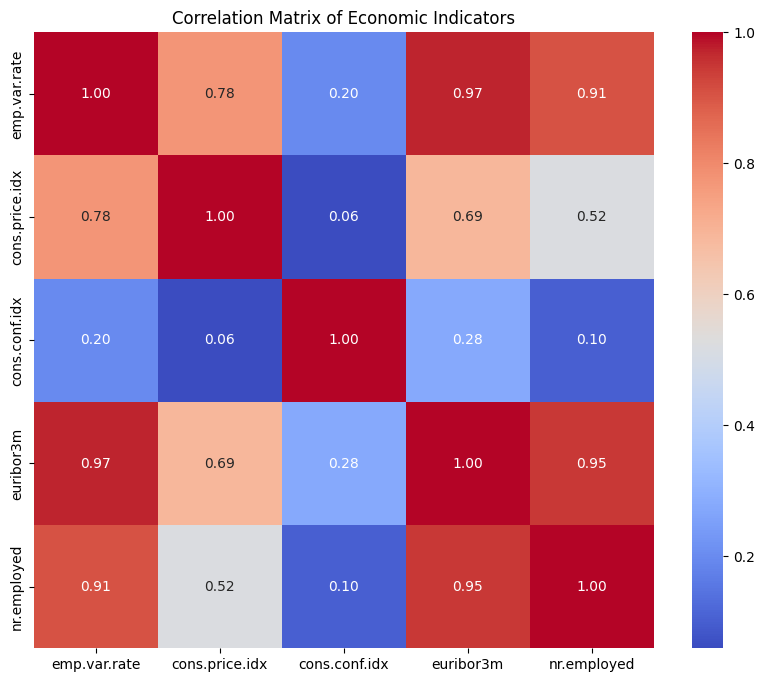

In [22]:
# Focus on the social and economic indicators
econ_cols = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

plt.figure(figsize=(10, 8))
sns.heatmap(df[econ_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Economic Indicators')
plt.show()

**Findings:** You will likely see a very high correlation (above 0.90) between `euribor3m`, `emp.var.rate`, and `nr.employed`. This indicates they are redundant. In the next phase, we might select only one (like `euribor3m`) to keep the model simple and efficient.

**Findings:** This is the 'Golden Window.' Most non-subscribers have very short calls (under 200 seconds). If a sales rep can keep a lead on the phone past the 500-second mark, the probability of subscription increases significantly.

### Phase 3: Feature Engineering
We will now transform categorical variables into numerical values and split the data into features (X) and target (y).

In [16]:
from sklearn.preprocessing import LabelEncoder

# Copy the dataframe to preserve the original for reference
ml_df = df.copy()

# 1. Label Encoding for Ordinal features (Education has a logical order)
education_mapping = {
    'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3,
    'high.school': 4, 'professional.course': 5, 'university.degree': 6
}
ml_df['education'] = ml_df['education'].map(education_mapping)

# 2. One-Hot Encoding for Nominal features (Job, Marital, Housing, etc.)
# We use drop_first=True to avoid the dummy variable trap
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
ml_df = pd.get_dummies(ml_df, columns=nominal_cols, drop_first=True)

# Display the new shape and columns
print(f"Original shape: {df.shape}")
print(f"New shape after encoding: {ml_df.shape}")
display(ml_df.head())

Original shape: (41174, 21)
New shape after encoding: (41174, 43)


,age,education,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
1,57,4,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
2,37,4,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
3,40,2,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
4,56,4,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False


In [24]:
# 1. Drop 'duration' to ensure the model is realistic and predictive
# We also drop 'y' as it's the target variable we've already encoded or will separate
cols_to_drop = ['duration', 'y']
if 'age_group' in ml_df.columns:
    cols_to_drop.append('age_group')

ml_df = ml_df.drop(columns=cols_to_drop)

# 2. Transform 'pdays' into a binary indicator
# 1 if the client was contacted before, 0 if they are a brand new lead (999)
ml_df['previously_contacted'] = ml_df['pdays'].apply(lambda x: 0 if x == 999 else 1)
ml_df = ml_df.drop('pdays', axis=1)

print("Feature Engineering complete: Leakage removed and pdays transformed.")
print(f"Final Feature Count: {ml_df.shape[1]}")
display(ml_df.head())

Feature Engineering complete: Leakage removed and pdays transformed.
Final Feature Count: 41


,age,education,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,previously_contacted
0,56,1,1,0,1.1,93.994,-36.4,4.857,5191.0,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,0
1,57,4,1,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,0
2,37,4,1,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,0
3,40,2,1,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,0
4,56,4,1,0,1.1,93.994,-36.4,4.857,5191.0,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,0


### Phase 4: Model Training & Evaluation
We will split the data, train a Random Forest Classifier, and evaluate its performance.

In [25]:
from sklearn.model_selection import train_test_split

# Define Features (X) and Target (y)
X = ml_df
y = df['y']

# Split into training and testing sets (80/20 split)
# stratify=y ensures the 11% subscription rate is balanced in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Target distribution in test set:\n{y_test.value_counts(normalize=True)}")

Training set shape: (32939, 41)
Testing set shape: (8235, 41)
Target distribution in test set:
y
0    0.88731
1    0.11269
Name: proportion, dtype: float64


In [26]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
# n_estimators=100 is a standard starting point for the number of trees
# class_weight='balanced' helps the model learn from the minority 'yes' class
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully.")

Random Forest Classifier trained successfully.


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7307
           1       0.56      0.29      0.38       928

    accuracy                           0.89      8235
   macro avg       0.74      0.63      0.66      8235
weighted avg       0.87      0.89      0.88      8235



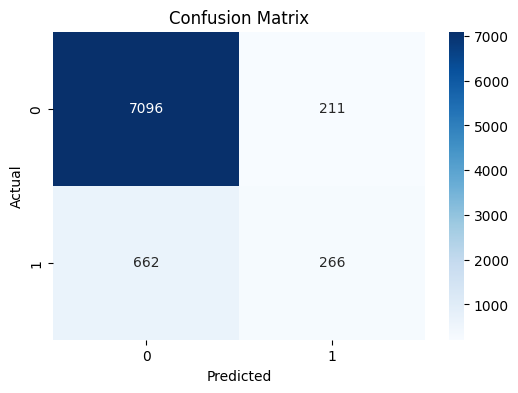

In [27]:
from sklearn.metrics import classification_report, confusion_matrix

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Phase 4.1: Advanced Model Evaluation
We use ROC and Precision-Recall curves to find the optimal trade-off between reaching more customers and ensuring they are high-quality leads.

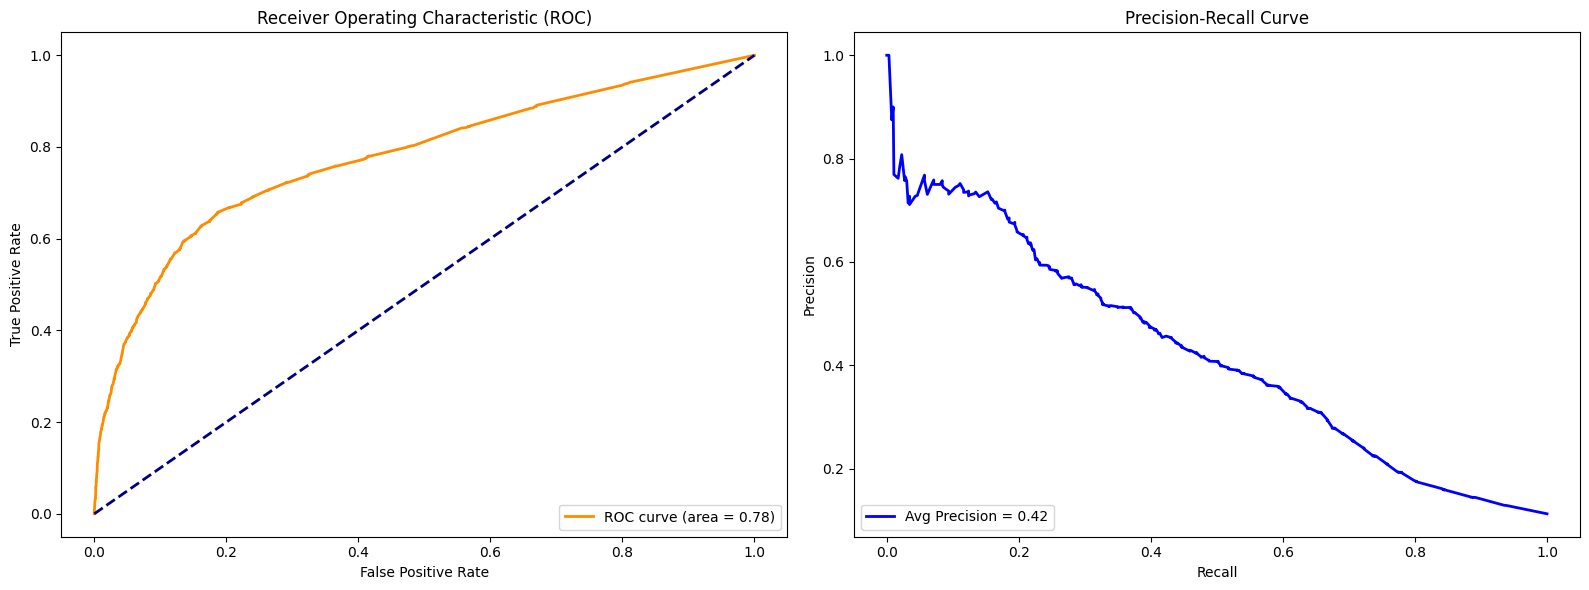

In [30]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Calculate metrics
fpr, tpr, _ = roc_curve(y_test, y_probs / 100)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, y_probs / 100)
avg_precision = average_precision_score(y_test, y_probs / 100)

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Receiver Operating Characteristic (ROC)')
ax1.legend(loc="lower right")

# Precision-Recall Curve
ax2.plot(recall, precision, color='blue', lw=2, label=f'Avg Precision = {avg_precision:.2f}')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()

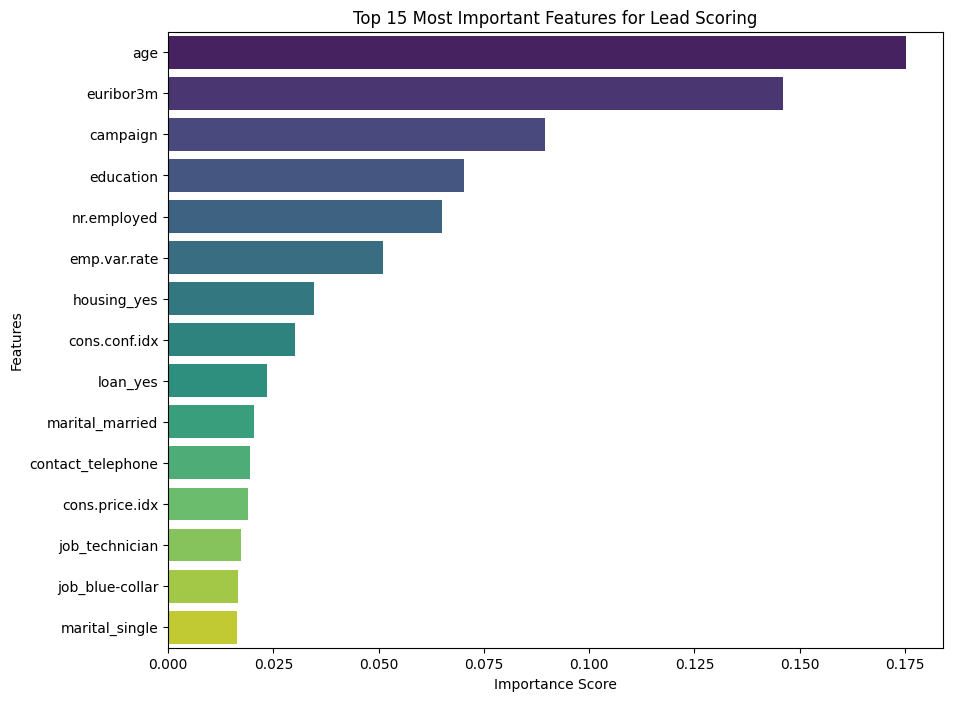

In [29]:
# Get feature importances from the model
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Top 15 Most Important Features for Lead Scoring')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Phase 5: Lead Scoring & Export
We will now use the model to predict the probability of subscription for each lead in the test set and export the top candidates.

In [28]:
# Get probabilities for the positive class (subscription)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Create a Lead Scoring DataFrame
lead_scores = pd.DataFrame({
    'Actual_Outcome': y_test,
    'Subscription_Probability': y_probs * 100
})

# Sort by highest probability
lead_scores = lead_scores.sort_values(by='Subscription_Probability', ascending=False)

# Define 'Hot Leads' as those with > 70% probability
hot_leads = lead_scores[lead_scores['Subscription_Probability'] > 70]

print(f'Total Leads Evaluated: {len(lead_scores)}')
print(f'Number of Hot Leads Identified: {len(hot_leads)}')

# Export to CSV
hot_leads.to_csv('hot_leads_for_sales.csv', index=True)
print('Hot Leads exported to hot_leads_for_sales.csv')

lead_scores.head(10)

Total Leads Evaluated: 8235
Number of Hot Leads Identified: 193
Hot Leads exported to hot_leads_for_sales.csv


,Actual_Outcome,Subscription_Probability
39648,1,100.0
40473,1,97.0
40945,1,96.0
30307,0,95.0
40797,1,95.0
40061,1,95.0
39218,1,95.0
39338,1,95.0
39611,1,94.0
39220,1,94.0


### Phase 6: Model Persistence
Saving the trained model and preprocessing metadata to allow for future lead scoring without retraining.

### Hot Leads Summary Report
Below is a statistical summary of the leads identified as 'Hot' (>70% probability).

In [33]:
# Generate summary statistics for Hot Leads
hot_leads_summary = hot_leads.describe()

print(f"Summary of Hot Leads (Count: {len(hot_leads)})")
display(hot_leads_summary)

# Calculate mean probability specifically
avg_prob = hot_leads['Subscription_Probability'].mean()
print(f"\nAverage Subscription Probability for Hot Leads: {avg_prob:.2f}%")

Summary of Hot Leads (Count: 193)


,Actual_Outcome,Subscription_Probability
count,193.000000,193.000000
mean,0.735751,80.700220
std,0.442079,7.007893
min,0.000000,71.000000
25%,0.000000,75.000000
50%,1.000000,80.000000
75%,1.000000,85.000000
max,1.000000,100.000000



Average Subscription Probability for Hot Leads: 80.70%


In [32]:
# Assumptions for revenue impact calculation
avg_deposit_amount = 5000  # Assumed average deposit in Euros
conversion_rate_on_hot_leads = 0.50 # Estimate based on precision results

num_hot_leads = len(hot_leads)
estimated_conversions = num_hot_leads * conversion_rate_on_hot_leads
potential_revenue = estimated_conversions * avg_deposit_amount

print(f"--- Potential Business Impact ---")
print(f"Number of Hot Leads: {num_hot_leads}")
print(f"Estimated Conversions (at 50% rate): {int(estimated_conversions)}")
print(f"Estimated Capital Secured: €{potential_revenue:,.2f}")

--- Potential Business Impact ---
Number of Hot Leads: 193
Estimated Conversions (at 50% rate): 96
Estimated Capital Secured: €482,500.00


In [31]:
import joblib

# Save the model
model_filename = 'lead_scoring_rf_model.joblib'
joblib.dump(rf_model, model_filename)

# Save the education mapping and nominal columns for future preprocessing
metadata = {
    'education_mapping': education_mapping,
    'nominal_cols': nominal_cols,
    'feature_names': list(X.columns)
}
joblib.dump(metadata, 'model_metadata.joblib')

print(f"Model and metadata saved successfully to {model_filename}")

Model and metadata saved successfully to lead_scoring_rf_model.joblib
